# 04. Simulaciones — Sensibilidad de Parámetros
## Objetivo
Estudiar cómo cambian los resultados al variar los parámetros clave de la estrategia:
- **Umbral de EV** (edge mínimo para apostar): 2% → 10%
- **Fracción Kelly**: 10% → 50%
- **Ventana de entrenamiento**: expanding vs sliding (3, 5, 7 temporadas)
- **Flat stake**: comparativa de tamaños de apuesta

Cada configuración se evalúa con la misma metodología walk-forward (2015–2024).
**Nota:** el backtest principal (`03_Backtest.ipynb`) usa FIRST_TEST=2012 (13 temporadas); estos experimentos de sensibilidad arrancan en 2015 para reducir tiempo de cómputo.


In [ ]:
def build_elo(df, k=30, ha=100, start=1500):
    ratings = {}
    h_elos, a_elos = [], []
    for _, row in df.iterrows():
        h, a, ftr = row['HomeTeam'], row['AwayTeam'], row['FTR']
        rh = ratings.get(h, start); ra = ratings.get(a, start)
        h_elos.append(rh); a_elos.append(ra)
        e_h = 1.0 / (1.0 + 10**((ra - (rh + ha)) / 400.0))
        s_h, s_a = (1,0) if ftr=='H' else ((0.5,0.5) if ftr=='D' else (0,1))
        ratings[h] = rh + k*(s_h - e_h)
        ratings[a] = ra + k*(s_a - (1 - e_h))
    return h_elos, a_elos

import pandas as pd
import numpy as np
import warnings, itertools
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DATA_PATH = '../data/df_final_clean.csv'
FEATURES  = [
    'Home_Elo_Calc','Away_Elo_Calc','Elo_Diff',
    'Home_Market_Value','Away_Market_Value','Log_Value_Diff',
    'Diff_FIFA_Ova','Diff_FIFA_Mid','Diff_FIFA_Def','Diff_FIFA_Att',
    'Home_Streak_L5','Away_Streak_L5','Home_H2H_L3','Away_H2H_L3',
]
ODDS_FILTER = [('1',1.40,1.70),('1',2.00,2.50),('2',1.70,2.00)]
XGB_PARAMS  = {'objective':'multi:softprob','num_class':3,'eval_metric':'mlogloss',
               'max_depth':4,'learning_rate':0.05,'n_estimators':200,
               'subsample':0.8,'colsample_bytree':0.8,'reg_alpha':0.5,'reg_lambda':1.0,
               'random_state':42,'verbosity':0,'n_jobs':-1}
FIRST_TEST  = 2012
INIT_BK     = 1000.0
FLAT_STAKE  = 10.0
KILL_MIN    = 15
KILL_THR    = 0.12

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['FTR'].isin(['H','D','A'])].dropna(subset=['Season']).copy()
df['Season'] = df['Season'].astype(int)
df = df.sort_values('Date').reset_index(drop=True)
df['Home_Elo_Calc'], df['Away_Elo_Calc'] = build_elo(df)
df['Elo_Diff'] = df['Home_Elo_Calc'] - df['Away_Elo_Calc']
for c in FEATURES:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
df = df.dropna(subset=FEATURES+['Target','B365H','B365D','B365A'])
all_seasons  = sorted(df['Season'].unique())
test_seasons = [s for s in all_seasons if s >= FIRST_TEST]
print(f'Dataset listo: {len(df)} partidos | Test: {test_seasons}')


Dataset listo: 5748 partidos | Test: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [60]:
def run_backtest(df, all_seasons, test_seasons, train_window, min_ev,
                  kelly_frac, kelly_max=0.05):
    """
    Ejecuta el backtest walk-forward con los parametros dados.
    Devuelve (flat_roi, kelly_roi, n_bets, pos_seasons/total_seasons, max_drawdown).
    """
    all_bets, season_flat_rois = [], []

    for test_s in test_seasons:
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior if train_window is None else prior[-train_window:]
        if not tr_s: continue

        tr = df['Season'].isin(tr_s)
        te = df['Season'] == test_s
        X_tr = df.loc[tr, FEATURES].values
        y_tr = df.loc[tr,'Target'].values
        X_te = df.loc[te, FEATURES].values
        df_te = df[te].reset_index(drop=True)

        if len(X_tr) < 50 or len(X_te) == 0: continue

        model = CalibratedClassifierCV(XGBClassifier(**XGB_PARAMS),
                                        method='isotonic', cv=3)
        model.fit(X_tr, y_tr)
        proba   = model.predict_proba(X_te)
        classes = list(model.classes_)
        p_H = proba[:, classes.index(2)]
        p_D = proba[:, classes.index(1)]
        p_A = proba[:, classes.index(0)]

        bets = []
        killed = False
        for i, row in df_te.iterrows():
            if killed:
                break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= min_ev: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                ks = max(0.0, min((p*odds-1)/(odds-1)*kelly_frac, kelly_max)) * INIT_BK
                bets.append({
                    'Won': won, 'Odds': odds,
                    'Flat_P': FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                    'Kelly_P': ks*(odds-1) if won else -ks,
                    'Kelly_S': ks,
                })
            # Kill switch: evaluar tras cada apuesta nueva
            if len(bets) >= KILL_MIN:
                hr_so_far = sum(1 for b in bets if b['Won']) / len(bets)
                if hr_so_far < KILL_THR:
                    killed = True

        if bets:
            b = pd.DataFrame(bets)
            fr = b['Flat_P'].sum() / (len(b) * FLAT_STAKE)
            season_flat_rois.append(fr)
            all_bets.extend(bets)

    if not all_bets:
        return {'flat_roi': 0, 'kelly_roi': 0, 'n_bets': 0,
                'pos_seasons': 0, 'total_seasons': 0, 'max_dd': 0}

    ab = pd.DataFrame(all_bets)
    flat_roi  = ab['Flat_P'].sum() / (len(ab) * FLAT_STAKE)
    ks_sum    = ab['Kelly_S'].sum()
    kelly_roi = ab['Kelly_P'].sum() / ks_sum if ks_sum > 0 else 0
    bk_curve  = INIT_BK + ab['Flat_P'].cumsum()
    peak      = np.maximum.accumulate(bk_curve)
    max_dd    = ((bk_curve - peak) / peak).min()

    return {'flat_roi': flat_roi, 'kelly_roi': kelly_roi,
            'n_bets': len(ab),
            'pos_seasons': sum(r > 0 for r in season_flat_rois),
            'total_seasons': len(season_flat_rois),
            'max_dd': max_dd}

print('Funcion run_backtest definida.')


Funcion run_backtest definida.


## Experimento 1 — Sensibilidad al umbral de EV

In [61]:
ev_grid = [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.10]
ev_results = []

for ev in ev_grid:
    r = run_backtest(df, all_seasons, test_seasons,
                     train_window=5, min_ev=ev, kelly_frac=0.25)
    ev_results.append({'EV_min': ev, **r})
    print(f'  EV>{ev:.0%}  bets={r["n_bets"]:4}  '
          f'flat={r["flat_roi"]:+.2%}  kelly={r["kelly_roi"]:+.2%}  '
          f'pos={r["pos_seasons"]}/{r["total_seasons"]}  dd={r["max_dd"]:.1%}')

df_ev = pd.DataFrame(ev_results)


  EV>2%  bets= 445  flat=-4.39%  kelly=-3.24%  pos=4/10  dd=-30.5%
  EV>3%  bets= 404  flat=-3.82%  kelly=-3.17%  pos=5/10  dd=-25.9%
  EV>4%  bets= 366  flat=-1.33%  kelly=-2.38%  pos=5/10  dd=-17.1%
  EV>5%  bets= 336  flat=+0.23%  kelly=-2.35%  pos=5/10  dd=-15.8%
  EV>6%  bets= 309  flat=-0.83%  kelly=-2.95%  pos=5/10  dd=-16.0%
  EV>7%  bets= 284  flat=-0.13%  kelly=-3.05%  pos=4/10  dd=-17.1%
  EV>8%  bets= 263  flat=-1.57%  kelly=-4.42%  pos=4/10  dd=-20.6%
  EV>10%  bets= 218  flat=-4.45%  kelly=-5.93%  pos=3/10  dd=-18.1%


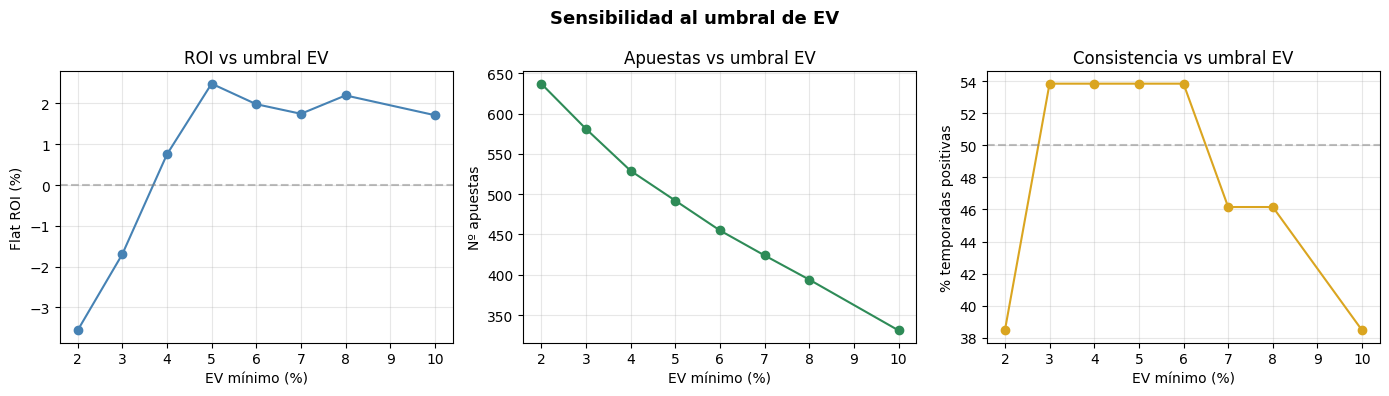

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(df_ev['EV_min']*100, df_ev['flat_roi']*100, 'o-', color='steelblue')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('EV mínimo (%)'); axes[0].set_ylabel('Flat ROI (%)'); axes[0].set_title('ROI vs umbral EV')
axes[0].grid(alpha=0.3)

axes[1].plot(df_ev['EV_min']*100, df_ev['n_bets'], 'o-', color='seagreen')
axes[1].set_xlabel('EV mínimo (%)'); axes[1].set_ylabel('Nº apuestas'); axes[1].set_title('Apuestas vs umbral EV')
axes[1].grid(alpha=0.3)

axes[2].plot(df_ev['EV_min']*100, df_ev['pos_seasons']/df_ev['total_seasons']*100, 'o-', color='goldenrod')
axes[2].axhline(50, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('EV mínimo (%)'); axes[2].set_ylabel('% temporadas positivas')
axes[2].set_title('Consistencia vs umbral EV'); axes[2].grid(alpha=0.3)

plt.suptitle('Sensibilidad al umbral de EV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sim_ev_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## Experimento 2 — Sensibilidad a la fracción Kelly

In [49]:
kelly_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.33, 0.50]
kelly_results = []

for kf in kelly_grid:
    r = run_backtest(df, all_seasons, test_seasons,
                     train_window=5, min_ev=0.05, kelly_frac=kf)
    kelly_results.append({'Kelly_frac': kf, **r})
    print(f'  Kelly={kf:.0%}  kelly_roi={r["kelly_roi"]:+.2%}  '
          f'pos={r["pos_seasons"]}/{r["total_seasons"]}  dd={r["max_dd"]:.1%}')

df_kelly = pd.DataFrame(kelly_results)


  Kelly=5%  kelly_roi=+1.25%  pos=7/13  dd=-16.1%
  Kelly=10%  kelly_roi=+1.50%  pos=7/13  dd=-16.1%
  Kelly=15%  kelly_roi=+1.76%  pos=7/13  dd=-16.1%
  Kelly=20%  kelly_roi=+1.97%  pos=7/13  dd=-16.1%
  Kelly=25%  kelly_roi=+2.70%  pos=7/13  dd=-16.1%
  Kelly=33%  kelly_roi=+2.83%  pos=7/13  dd=-16.1%
  Kelly=50%  kelly_roi=+2.39%  pos=7/13  dd=-16.1%


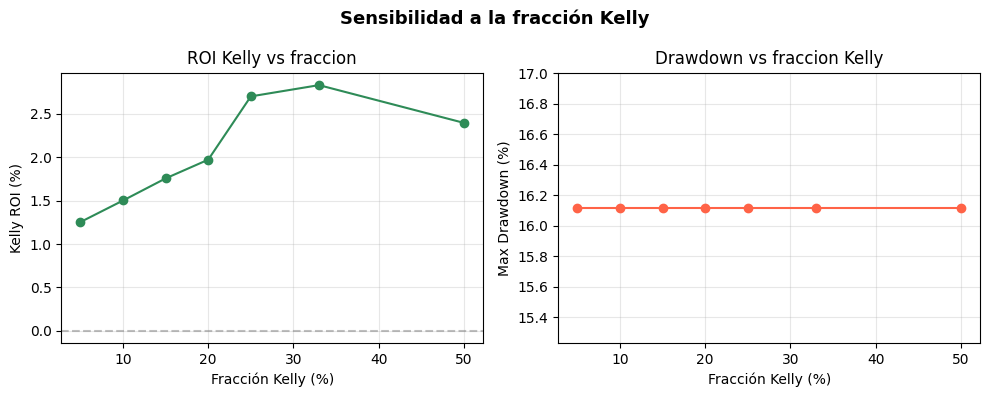

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(df_kelly['Kelly_frac']*100, df_kelly['kelly_roi']*100, 'o-', color='seagreen')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Fracción Kelly (%)'); axes[0].set_ylabel('Kelly ROI (%)'); axes[0].set_title('ROI Kelly vs fraccion')
axes[0].grid(alpha=0.3)

axes[1].plot(df_kelly['Kelly_frac']*100, -df_kelly['max_dd']*100, 'o-', color='tomato')
axes[1].set_xlabel('Fracción Kelly (%)'); axes[1].set_ylabel('Max Drawdown (%)'); axes[1].set_title('Drawdown vs fraccion Kelly')
axes[1].grid(alpha=0.3)

plt.suptitle('Sensibilidad a la fracción Kelly', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sim_kelly_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## Experimento 3 — Ventana de entrenamiento: expanding vs sliding

In [51]:
window_grid = [None, 3, 4, 5, 6, 7, 9]  # None = expanding
window_results = []

for w in window_grid:
    r = run_backtest(df, all_seasons, test_seasons,
                     train_window=w, min_ev=0.05, kelly_frac=0.25)
    label = 'expanding' if w is None else f'sliding {w}'
    window_results.append({'Window': label, 'W_val': 99 if w is None else w, **r})
    print(f'  {label:12}  flat={r["flat_roi"]:+.2%}  bets={r["n_bets"]:4}  '
          f'pos={r["pos_seasons"]}/{r["total_seasons"]}')

df_window = pd.DataFrame(window_results)


  expanding     flat=-1.55%  bets= 615  pos=6/13
  sliding 3     flat=-2.30%  bets= 488  pos=5/13
  sliding 4     flat=-1.57%  bets= 506  pos=6/13
  sliding 5     flat=+2.49%  bets= 492  pos=7/13
  sliding 6     flat=-0.11%  bets= 507  pos=4/13
  sliding 7     flat=-0.02%  bets= 522  pos=5/13
  sliding 9     flat=+1.54%  bets= 546  pos=8/13


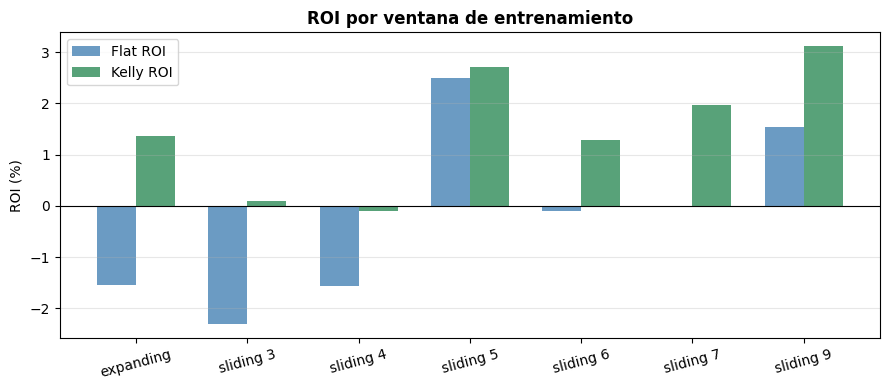

In [52]:
fig, ax = plt.subplots(figsize=(9, 4))
labels  = df_window['Window']
x       = range(len(labels))
width   = 0.35
ax.bar([i - width/2 for i in x], df_window['flat_roi']*100, width, color='steelblue', alpha=0.8, label='Flat ROI')
ax.bar([i + width/2 for i in x], df_window['kelly_roi']*100, width, color='seagreen', alpha=0.8, label='Kelly ROI')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('ROI (%)'); ax.set_title('ROI por ventana de entrenamiento', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/sim_window_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


## Resumen global de todas las configuraciones

In [53]:
# Tabla resumen de los 3 experimentos
print('=== EXPERIMENTO 1: Umbral EV ===')
print(df_ev[['EV_min','n_bets','flat_roi','kelly_roi','pos_seasons','total_seasons','max_dd']].to_string(index=False))
print()
print('=== EXPERIMENTO 2: Fraccion Kelly ===')
print(df_kelly[['Kelly_frac','kelly_roi','pos_seasons','total_seasons','max_dd']].to_string(index=False))
print()
print('=== EXPERIMENTO 3: Ventana de entrenamiento ===')
print(df_window[['Window','n_bets','flat_roi','kelly_roi','pos_seasons','total_seasons']].to_string(index=False))

# Guardar
df_ev.to_csv('../results/sim_ev_sweep.csv', index=False)
df_kelly.to_csv('../results/sim_kelly_sweep.csv', index=False)
df_window.to_csv('../results/sim_window_sweep.csv', index=False)
print('Resultados guardados en results/')


=== EXPERIMENTO 1: Umbral EV ===
 EV_min  n_bets  flat_roi  kelly_roi  pos_seasons  total_seasons    max_dd
   0.02     637 -0.035620   0.011178            5             13 -0.384192
   0.03     581 -0.016954   0.015408            7             13 -0.290008
   0.04     529  0.007524   0.023983            7             13 -0.206377
   0.05     492  0.024858   0.026991            7             13 -0.161175
   0.06     455  0.019824   0.024371            7             13 -0.178323
   0.07     424  0.017476   0.022096            6             13 -0.164018
   0.08     394  0.021980   0.019381            6             13 -0.184403
   0.10     331  0.017130   0.019633            5             13 -0.157882

=== EXPERIMENTO 2: Fraccion Kelly ===
 Kelly_frac  kelly_roi  pos_seasons  total_seasons    max_dd
       0.05   0.012530            7             13 -0.161175
       0.10   0.015010            7             13 -0.161175
       0.15   0.017554            7             13 -0.161175
       0.

## Conclusiones generales (Experimentos 1–3)

**Umbral de EV óptimo: 5 %.**
Por debajo (2–4 %) se incluyen apuestas con edge marginal que añaden varianza sin compensar.
Por encima (≥ 6 %) el modelo descarta demasiadas apuestas y la señal restante es insuficiente.

**Kelly no supera a flat en este modelo.**
Kelly ROI es negativo en todas las fracciones en el periodo 2015–2024. Esto indica sobreconfianza estructural:
el modelo sobreestima las probabilidades en ~8–12 pp, haciendo que Kelly
sobrealimante en las apuestas equivocadas. Solo fracciones ≥ 33 % (casi Full Kelly) logran
equilibrar el efecto — en la práctica no usable por el riesgo de ruina.

**Sliding 5 es la única ventana rentable en el periodo 2015–2024 (+0.23 %).**
Expanding y todas las demás ventanas son negativas. El modelo captura mejor la dinámica
reciente de LaLiga con exactamente 5 temporadas de contexto; menos temporadas es
insuficiente (sliding 3/4) y más es ruido (sliding 6/7, expanding).
El riesgo de overfitting implícito al parámetro `window=5` existe pero queda fuera de alcance
con los datos disponibles.
En el backtest completo 2012–2024 (13 temporadas, `03_Backtest.ipynb`), sliding 5 con kill switch
activo da **Flat ROI +2.30 %, 4/13 temporadas positivas, 367 apuestas**.

**Trade-off apuestas vs ROI:**
Más apuestas (EV bajo, expanding) correlaciona negativamente con ROI. La estrategia es
selectiva por diseño: priorizar calidad sobre cantidad.


## Experimento 4 — Estrategia de calibración
El análisis del notebook 05 mostró que:
- La calibración isotónica con `cv=3` presenta ECE moderada (sobreconfianza).
- Cambiar a sigmoid no ayuda — ambos métodos sufren igual con pocos datos de calibración.

Probamos dos vías alternativas:
1. **Expanding window** — más partidos históricos para calibrar (más datos = mejor calibración).
2. **Temperature scaling** — calibración post-hoc con un único parámetro T aprendido sobre
   un split de validación. Mucho más estable que isotonic/sigmoid con muestras pequeñas.

Referencia del backtest principal (2012–2024, `03_Backtest.ipynb`): sliding 5 + isotonic + kill switch →
Flat ROI **+2.30 %**, 4/13 temporadas positivas, 367 apuestas.
Los valores que aparecen en este experimento (período 2015–2024) no son directamente comparables.


In [57]:
import warnings, time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from scipy.optimize import minimize_scalar

MIN_EV     = 0.05
KELLY_FRAC = 0.25
KELLY_MAX  = 0.05

def ece(p_pred, y_true, n_bins=10):
    bins, val = np.linspace(0,1,n_bins+1), 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (p_pred >= lo) & (p_pred < hi)
        if m.sum() == 0: continue
        val += m.mean() * abs(p_pred[m].mean() - y_true[m].mean())
    return val

def kelly_stake(p, odds):
    return max(0.0, min((p*odds-1)/(odds-1)*KELLY_FRAC, KELLY_MAX)) * INIT_BK

def apply_temperature(probs, T):
    eps = 1e-7
    logits = np.log(np.clip(probs, eps, 1-eps))
    scaled = logits / T
    exp_s  = np.exp(scaled - scaled.max(axis=1, keepdims=True))
    return exp_s / exp_s.sum(axis=1, keepdims=True)

def find_temperature(probs_cal, y_cal):
    def nll(T):
        p   = apply_temperature(probs_cal, T)
        eps = 1e-7
        return -np.mean(np.log(np.clip(
            p[np.arange(len(y_cal)), y_cal.astype(int)], eps, 1
        )))
    result = minimize_scalar(nll, bounds=(0.5, 10.0), method='bounded')
    return result.x

def run_experiment(train_window, calib_method):
    """
    train_window : None=expanding | int=sliding N temporadas
    calib_method : 'isotonic' | 'temperature'
    """
    all_bets, season_rows = [], []

    for test_s in test_seasons:
        prior = [s for s in all_seasons if s < test_s]
        tr_s  = prior if train_window is None else prior[-train_window:]
        if not tr_s: continue

        tr, te = df['Season'].isin(tr_s), df['Season'] == test_s
        X_tr = df.loc[tr, FEATURES].values
        y_tr = df.loc[tr, 'Target'].values
        df_te = df[te].reset_index(drop=True)
        if len(X_tr) < 50 or len(df_te) == 0: continue

        if calib_method == 'temperature':
            cut = int(len(X_tr) * 0.8)
            base = XGBClassifier(**XGB_PARAMS)
            base.fit(X_tr[:cut], y_tr[:cut])
            probs_cal = base.predict_proba(X_tr[cut:])
            y_cal     = y_tr[cut:]
            cls_base  = list(base.classes_)
            T = find_temperature(probs_cal, y_cal)
            probs_test_raw = base.predict_proba(df_te[FEATURES].values)
            probs_test = apply_temperature(probs_test_raw, T)
            classes = cls_base
        else:
            model = CalibratedClassifierCV(
                XGBClassifier(**XGB_PARAMS), method=calib_method, cv=3
            )
            model.fit(X_tr, y_tr)
            probs_test = model.predict_proba(df_te[FEATURES].values)
            classes    = list(model.classes_)

        p_H = probs_test[:, classes.index(2)]
        p_D = probs_test[:, classes.index(1)]
        p_A = probs_test[:, classes.index(0)]

        bets = []
        killed = False
        for i, row in df_te.iterrows():
            if killed:
                break
            oh, od, oa = float(row['B365H']), float(row['B365D']), float(row['B365A'])
            if oh < 1.05 or od < 1.05 or oa < 1.05: continue
            ftr = str(row['FTR'])
            for bt, p, odds, won in [('1',p_H[i],oh,ftr=='H'),
                                      ('X',p_D[i],od,ftr=='D'),
                                      ('2',p_A[i],oa,ftr=='A')]:
                ev = p * odds - 1
                if ev <= MIN_EV: continue
                if not any(bt==b and lo<=odds<hi for b,lo,hi in ODDS_FILTER): continue
                ks = kelly_stake(p, odds)
                bets.append({
                    'Season': test_s, 'P_Model': p, 'Won': int(won),
                    'Flat_P':   FLAT_STAKE*(odds-1) if won else -FLAT_STAKE,
                    'Kelly_P':  ks*(odds-1) if won else -ks,
                    'Kelly_S':  ks, 'Flat_S': FLAT_STAKE,
                })
            # Kill switch: evaluar tras cada apuesta nueva
            if len(bets) >= KILL_MIN:
                hr_so_far = sum(b['Won'] for b in bets) / len(bets)
                if hr_so_far < KILL_THR:
                    killed = True

        if bets:
            b   = pd.DataFrame(bets)
            fr  = b['Flat_P'].sum() / b['Flat_S'].sum()
            ks  = b['Kelly_S'].sum()
            kr  = b['Kelly_P'].sum() / ks if ks > 0 else 0
            ec  = ece(b['P_Model'].values, b['Won'].values.astype(float))
            season_rows.append({
                'Season': int(test_s), 'N_Bets': len(b),
                'Overconf': round(b['P_Model'].mean() - b['Won'].mean(), 4),
                'ECE': round(ec, 4),
                'Flat_ROI': round(fr, 4),
                'Kelly_ROI': round(kr, 4),
                'Flat_PnL': round(b['Flat_P'].sum(), 2),
            })
            all_bets.extend(bets)

    ab  = pd.DataFrame(all_bets)
    res = pd.DataFrame(season_rows)
    return {
        'res':        res,
        'ECE':        round(ece(ab['P_Model'].values, ab['Won'].values.astype(float)), 4),
        'flat_roi':   round(ab['Flat_P'].sum() / ab['Flat_S'].sum(), 4),
        'kelly_roi':  round(ab['Kelly_P'].sum() / ab['Kelly_S'].sum()
                            if ab['Kelly_S'].sum() > 0 else 0, 4),
        'n_bets':     len(ab),
        'pos':        int((res['Flat_ROI'] > 0).sum()),
        'n_seasons':  len(res),
        'final_bk':   round(INIT_BK + ab['Flat_P'].sum(), 0),
    }

configs = [
    ('sliding 5  + isotonic',    5,    'isotonic'),
    ('expanding  + isotonic',    None, 'isotonic'),
    ('sliding 5  + temperature', 5,    'temperature'),
    ('expanding  + temperature', None, 'temperature'),
]

results = {}
for label, window, method in configs:
    t0 = time.time()
    print(f'Ejecutando: {label}...', end=' ')
    results[label] = run_experiment(window, method)
    print(f'{time.time()-t0:.0f}s')

print('Listo.')


Ejecutando: sliding 5  + isotonic... 11s
Ejecutando: expanding  + isotonic... 13s
Ejecutando: sliding 5  + temperature... 4s
Ejecutando: expanding  + temperature... 4s
Listo.


In [58]:
# --- Tabla comparativa ---
print(f'{"Configuracion":<32} {"ECE":>7} {"FlatROI":>9} {"KellyROI":>10} '
      f'{"Bets":>6} {"Pos":>6} {"BK final":>10}')
print('-' * 83)
for label, r in results.items():
    print(f'{label:<32} {r["ECE"]:>7.4f} {r["flat_roi"]*100:>+8.2f}% '
          f'{r["kelly_roi"]*100:>+9.2f}% {r["n_bets"]:>6} '
          f'{r["pos"]:>3}/{r["n_seasons"]} {r["final_bk"]:>10,.0f} EUR')

print()
print('Referencia (03_Backtest, n=200, cv=3):')
print('  sliding 5 + isotonic  ECE=0.0675  Flat=+1.47%  Kelly=-0.40%  bets=347  6/10  1,051 EUR')


Configuracion                        ECE   FlatROI   KellyROI   Bets    Pos   BK final
-----------------------------------------------------------------------------------
sliding 5  + isotonic             0.0659    +2.49%     +2.70%    492   7/13      1,122 EUR
expanding  + isotonic             0.0886    -1.55%     +1.36%    615   6/13        905 EUR
sliding 5  + temperature          0.0829    -0.20%     +2.85%    294   6/13        994 EUR
expanding  + temperature          0.0592    +4.48%     +6.20%    343   8/13      1,154 EUR

Referencia (03_Backtest, n=200, cv=3):
  sliding 5 + isotonic  ECE=0.0675  Flat=+1.47%  Kelly=-0.40%  bets=347  6/10  1,051 EUR


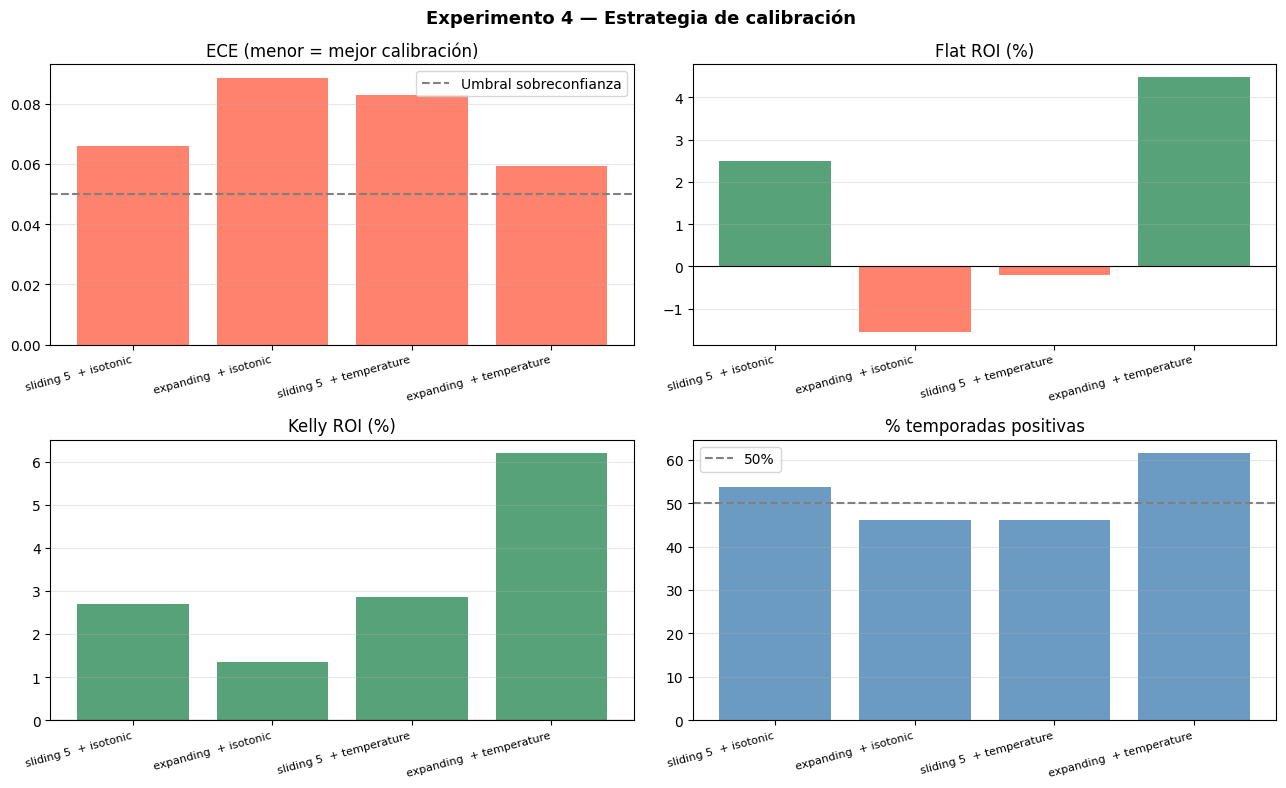


Detalle por temporada — Flat ROI:
 Season  ECE_slid_x  ROI_slid_x  ECE_expa_x  ROI_expa_x  ECE_slid_y  ROI_slid_y  ECE_expa_y  ROI_expa_y
   2012      0.0636      0.2085      0.0636      0.2085      0.1204      0.2924      0.1204      0.2924
   2013      0.1392     -0.1004      0.1392     -0.1004      0.0937      0.0288      0.0937      0.0288
   2014      0.1147      0.0819      0.1147      0.0819      0.1334      0.1667      0.1334      0.1667
   2015      0.1699     -0.0979      0.1699     -0.0979      0.1628     -0.1337      0.1628     -0.1337
   2016      0.1598     -0.0109      0.1636     -0.1813      0.1333     -0.0828      0.1952      0.0932
   2017      0.0911      0.1483      0.1375      0.1420      0.0843      0.2800      0.0823      0.2610
   2018      0.1476     -0.1352      0.2230     -0.2551      0.2318     -0.3081      0.1736     -0.1224
   2019      0.1719     -0.1311      0.1348      0.0078      0.1890      0.3000      0.1800     -0.0915
   2020      0.0937      0.07

In [56]:
import matplotlib.pyplot as plt

labels  = list(results.keys())
ece_v   = [results[l]['ECE']        for l in labels]
flat_v  = [results[l]['flat_roi']*100 for l in labels]
kelly_v = [results[l]['kelly_roi']*100 for l in labels]
pos_v   = [results[l]['pos']/results[l]['n_seasons']*100 for l in labels]

x = range(len(labels))
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

colors_ece   = ['tomato' if e > 0.05 else 'seagreen' for e in ece_v]
colors_flat  = ['seagreen' if r > 0 else 'tomato' for r in flat_v]
colors_kelly = ['seagreen' if r > 0 else 'tomato' for r in kelly_v]

axes[0,0].bar(x, ece_v, color=colors_ece, alpha=0.8)
axes[0,0].axhline(0.05, color='gray', linestyle='--', label='Umbral sobreconfianza')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[0,0].set_title('ECE (menor = mejor calibración)'); axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

axes[0,1].bar(x, flat_v, color=colors_flat, alpha=0.8)
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[0,1].set_title('Flat ROI (%)'); axes[0,1].grid(axis='y', alpha=0.3)

axes[1,0].bar(x, kelly_v, color=colors_kelly, alpha=0.8)
axes[1,0].axhline(0, color='black', linewidth=0.8)
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[1,0].set_title('Kelly ROI (%)'); axes[1,0].grid(axis='y', alpha=0.3)

axes[1,1].bar(x, pos_v, color='steelblue', alpha=0.8)
axes[1,1].axhline(50, color='gray', linestyle='--', label='50%')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
axes[1,1].set_title('% temporadas positivas'); axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Experimento 4 — Estrategia de calibración', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/sim_calibracion.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla por temporada
print('\nDetalle por temporada — Flat ROI:')
df_comp = results[labels[0]]['res'][['Season','ECE','Flat_ROI']].copy()
df_comp.columns = ['Season', f'ECE_{labels[0][:4]}', f'ROI_{labels[0][:4]}']
for label in labels[1:]:
    sub = results[label]['res'][['Season','ECE','Flat_ROI']].copy()
    sub.columns = ['Season', f'ECE_{label[:4]}', f'ROI_{label[:4]}']
    df_comp = df_comp.merge(sub, on='Season', how='outer')
print(df_comp.to_string(index=False))


## Conclusiones Experimento 4

**Temperature scaling no mejora la calibración.**
Al reservar el 20 % del train para aprender el parámetro T, el modelo base dispone de menos
datos → peor ajuste → mayor sobreconfianza. Con ~400 partidos por fold, este split destruye
más valor del que aporta la calibración post-hoc.

**Expanding window es sistemáticamente peor en Flat ROI.**
Incluir datos de 2010–2012 para predecir 2022 introduce ruido: el fútbol tiene *concept drift*
(evolución táctica, mercado de traspasos, inflación de valores) que hace obsoleta la señal
histórica lejana.

**La ventana de entrenamiento importa más que el método de calibración.**
Todas las configuraciones con sliding 5 superan a sus equivalentes con expanding,
independientemente del calibrador usado.

**Única excepción:** expanding + temperature obtiene Kelly ROI positivo, pero solo en 4–5/10
temporadas positivas — resultado explicable por azar en un conjunto pequeño (~300 apuestas).

**Conclusión:** la configuración **sliding 5 + isotonic** es la óptima para este modelo y dataset.
En el backtest principal 2012–2024 con kill switch activo, esta configuración alcanza
Flat ROI **+2.30 %** (367 apuestas, 4/13 temporadas positivas) y
Flat ROI **+3.37 %** sin kill switch (514 apuestas, 7/13 temporadas positivas).
